In [70]:
### Imports die man für das Projekt brauch
import pandas
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.pyplot import tight_layout
from pandas.conftest import ascending

df = pd.read_csv("global_tech_startups_2026.csv")

In [53]:
###Aufgabe 1 - Daten laden & erkunden###

####Nutze .info(), .describe() und .head(10)####
print(f"===df.info===\n{df.info()}\n")
print(f"===df.describe===\n{df.describe()}===\n")
print(f".head(10)===\n{df.head(10)}\n")

####Gib die Anzahl der einzigartigen Domains, Lander und Funding-Stages aus (.nunique(), .value_counts())####
print(f"===Einzigartige Domains, Länder und Funding-Stages aus (.nunique(), .value_counts())===")
domaincount = df['Domain'].nunique()
countrycount = df['Country'].nunique()
fundingstagecount = df['Funding_Stage'].nunique()

print(f"{domaincount} Einzigartige Domains")
print(f"{countrycount} Einzigartige Länder")
print(f"{fundingstagecount} Unique Funding-Stages\n")

####Prufe auf fehlende Werte mit .isnull().sum()####
fehlendewerte = df.isnull().sum()

print(f"===Prüfung auf fehlende Werte\n {fehlendewerte}")

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Company_ID                  25000 non-null  str    
 1   Domain                      25000 non-null  str    
 2   Founding_Year               25000 non-null  int64  
 3   Country                     25000 non-null  str    
 4   City                        25000 non-null  str    
 5   Funding_Stage               25000 non-null  str    
 6   Total_Funding_USD_Millions  25000 non-null  float64
 7   Valuation_USD_Millions      25000 non-null  float64
 8   Revenue_ARR_Millions        25000 non-null  float64
 9   Monthly_Burn_Rate_Millions  25000 non-null  float64
 10  Runway_Months_2024          25000 non-null  float64
 11  Peak_Headcount_2023         25000 non-null  int64  
 12  Layoffs_2024_2025           25000 non-null  int64  
 13  Current_Headcount_2026      25000 non-null

In [54]:
###Aufgabe 2 - Neue Kennzahlen berechnen###

####Berechne den Layoff-Anteil: Layoff_Rate = Layoffs / Peak_Headcount_2023 * 100####
df.columns = df.columns.str.strip()
df["Layoff_Rate"] = df["Layoffs_2024_2025"] / df["Peak_Headcount_2023"] * 100
df.to_csv("global_tech_startups_2026.csv", index=False)
print(f"===Spalte konnte eingeführt werden===")
print(df.head(10))

####Berechne das Valuation-Multiple: Val_Multiple = Valuation / Revenue_ARR (Achtung: Division durch 0 abfangen!)####
df.columns = df.columns.str.strip()
df["Val_Multiplite"] = df["Valuation_USD_Millions"] / df["Revenue_ARR_Millions"]
df.to_csv("global_tech_startups_2026.csv", index=False)
print(f"===Spalte konnte eingeführt werden===")
print(df.head(10))

####Berechne den Burn-Multiple: Burn_Multiple = Monthly_Burn_Rate * 12 / Revenue_ARR (wie effizient verbrennt das Startup Geld?)####
df.columns = df.columns.str.strip()
df["Burn_Multiple"] = df["Monthly_Burn_Rate_Millions"] * 12 / df["Revenue_ARR_Millions"]
df.to_csv("global_tech_startups_2026.csv", index=False)
print(f"===Spalte konnte eingeführt werden===")
print(df.head(10))

####Erstelle eine Spalte Startup_Age: 2026 minus Founding_Year####
df.columns = df.columns.str.strip()
df["Starup_Age"] = 2026 - df["Founding_Year"]
df.to_csv("global_tech_startups_2026.csv", index=False)
print(f"===Spalte konnte eingeführt werden===")
print(df.head(10))

print(f"===Alle neu eingeführten Spalten===\n"
      f"{df[['Company_ID', 'Layoff_Rate', 'Val_Multiplite', 'Burn_Multiple', 'Starup_Age']].head(10)}")


===Spalte konnte eingeführt werden===
  Company_ID         Domain  Founding_Year Country           City  \
0   B730AD52     HealthTech           2014  Canada       Montreal   
1   65A5F690    Web3/Crypto           2014   China        Beijing   
2   F106C853  Cybersecurity           2020     USA  San Francisco   
3   2BD798AF        FinTech           2023   India      Delhi NCR   
4   C5CB4451  Generative AI           2020     USA       New York   
5   22994DE8  Generative AI           2014   China       Shanghai   
6   F998B9AE  Generative AI           2017     USA       New York   
7   DFEF57C1         EdTech           2017      UK         Oxford   
8   569C2230        FinTech           2018     USA  San Francisco   
9   859D4768    ClimateTech           2013     USA          Miami   

  Funding_Stage  Total_Funding_USD_Millions  Valuation_USD_Millions  \
0          Seed                        1.64                   17.81   
1       Pre-IPO                      103.87                 

In [55]:
###Aufgabe 3 - Gruppenanalyse nach Domain (Branche)###

####Berechne je Domain: Anzahl Startups, Ø Funding, Ø Valuation, Ø Revenue_ARR####
df['Burn_Multiple'] = df.apply(
    lambda row: row['Monthly_Burn_Rate_Millions'] * 12 / row['Revenue_ARR_Millions']
    if row['Revenue_ARR_Millions'] > 0 else None,
    axis=1
)
####Nutze .groupby('Domain').agg({'Company_ID':'count', 'Total_Funding_USD_Millions':'mean', ...})####
domain_analysis = df.groupby("Domain").agg({
    "Company_ID":                 "count",
    "Total_Funding_USD_Millions": "mean",
    "Valuation_USD_Millions":     "mean",
    "Revenue_ARR_Millions":       "mean",
    "Burn_Multiple":              "mean"
})

####Benenne die Spalten nach der Aggregation sinnvoll um mit .rename(columns={...})####
domain_analysis = domain_analysis.rename(columns={
    "Company_ID":                 "Anzahl_Startups",
    "Total_Funding_USD_Millions": "Ø_Funding_Mio",
    "Valuation_USD_Millions":     "Ø_Valuation_Mio",
    "Revenue_ARR_Millions":       "Ø_Revenue_ARR_Mio",
    "Burn_Multiple":              "Ø_Burn_Multiple"
})

####Sortiere nach Ø Valuation absteigend und gib die Top 5 aus####
top5 = domain_analysis.sort_values("Ø_Valuation_Mio", ascending=False).head(5)
print("===Top 5 Domains nach Ø Valuation===")
print(top5.round(2))

####Welche Domain hat den hoechsten Ø Burn-Multiple? (neue Spalte aus Aufgabe 2)####
top_burn_domain = domain_analysis["Ø_Burn_Multiple"].idxmax()
top_burn_value  = domain_analysis.loc[top_burn_domain, "Ø_Burn_Multiple"]

print(f"\n=== Domain mit höchstem Ø Burn-Multiple ===")
print(f"{top_burn_domain}: {top_burn_value:.2f}x")

===Top 5 Domains nach Ø Valuation===
                     Anzahl_Startups  Ø_Funding_Mio  Ø_Valuation_Mio  \
Domain                                                                 
Generative AI                   4958         114.50           885.84   
SpaceTech                       1252          97.80           747.87   
Web3/Crypto                     2047          53.03           402.60   
Autonomous Vehicles             1248          46.65           376.42   
FinTech                         3060          41.68           344.52   

                     Ø_Revenue_ARR_Mio  Ø_Burn_Multiple  
Domain                                                   
Generative AI                    63.22             2.32  
SpaceTech                        50.31             2.38  
Web3/Crypto                      29.00             2.92  
Autonomous Vehicles              26.37             3.04  
FinTech                          25.52             3.04  

=== Domain mit höchstem Ø Burn-Multiple ===
Cyberse

In [56]:
###Aufgabe 4 - Layoff-Analyse 2024/2025###

####Filtere nur Startups die uberhaupt Layoffs hatten (Layoffs_2024_2025 > 0)####
filteredf = df[df["Layoff_Rate"] > 0]

####Zeigen Sie nur die gewünschte Spalte an (Werte)####
print(f"So viele Unternehmen haben Layoffs gehabt: {len(filteredf)}")

So viele Unternehmen haben Layoffs gehabt: 9710


In [67]:
###Aufgabe 5 - Startup-Uberlebensanalyse: Acquisition Status###

import pandas as pd

####Zahle wie viele Startups je Status gibt (Independent, Closed, Acquired, IPO ...)####
print("===Verteilung Acquisition_Status===")
print(df['Acquisition_Status'].value_counts())

####Berechne je Status den Ø Runway, Ø Revenue_ARR und Ø Layoff_Rate####
print("===Kennzahlen je Acquisition-Status===")
StatusWerte = df.groupby('Acquisition_Status').agg(
    Anzahl=('Company_ID', 'count'),
    Ø_Runway=('Runway_Months_2024', 'mean'),
    Ø_Revenue_ARR=('Revenue_ARR_Millions', 'mean'),
    Ø_Layoff_Rate=('Layoff_Rate', 'mean')
).round(2)
print(StatusWerte.sort_values('Ø_Runway'))

####Vergleich: Haben "Closed"-Startups einen niedrigeren Runway als "Independent"? Beweise es mit Zahlen####
RunwayGeschlossen = df[df['Acquisition_Status'] == 'Closed']['Runway_Months_2024'].mean()
RunwaySelbstständig = df[df['Acquisition_Status'] == 'Independent']['Runway_Months_2024'].mean()
print(f"\n--- Runway Vergleich ---")
print(f"Closed-Startups:      Ø Runway = {RunwayGeschlossen:.2f} Monate")
print(f"Independent-Startups: Ø Runway = {RunwaySelbstständig:.2f} Monate")
print(f"→ Geschlossene-Startups haben {RunwaySelbstständig - RunwayGeschlossen:.2f} Monate weniger Runway als Independent.")

####Analysiere: Welcher Investor-Tier hat die meisten "Closed"-Startups?####
print("===Investor-Tier der Closed-Startups===")
TierGeschlossen = (
    df[df['Acquisition_Status'] == 'Closed']
    .groupby('Investor_Tier')['Company_ID']
    .count()
    .sort_values(ascending=False)
)
print(TierGeschlossen)
print(f"\nInvestor-Tier mit meisten Geschlossenen-Startups: {TierGeschlossen.idxmax()} "
      f"({TierGeschlossen.max()} Startups)")

####Bonus: Welcher AI_Adoption_Level korreliert am meisten mit dem Status "Closed"?####
print("===BONUS: AI_Adoption_Level der Closed-Startups===")
GeschlossenWegenAI = (
    df[df['Acquisition_Status'] == 'Geschlossen']
    .groupby('AI_Adoption_Level')['Company_ID']
    .count()
    .sort_values(ascending=False)
)
####Prozentual####
closed_total = GeschlossenWegenAI.sum()
GeschlossenWegenAIpct= (GeschlossenWegenAI / closed_total * 100).round(2)
print(pd.DataFrame({'Anzahl': GeschlossenWegenAI, 'Anteil_%': GeschlossenWegenAIpct}))


===Verteilung Acquisition_Status===
Acquisition_Status
Independent             15456
Closed                   5087
Acquired                 2636
Acquired (Fire Sale)     1142
IPO                       679
Name: count, dtype: int64
===Kennzahlen je Acquisition-Status===
                      Anzahl  Ø_Runway  Ø_Revenue_ARR  Ø_Layoff_Rate
Acquisition_Status                                                  
Acquired (Fire Sale)    1142      7.88          20.10          64.34
Closed                  5087     10.90          29.01          28.71
Acquired                2636     12.58          35.20          10.78
Independent            15456     12.80          35.28          10.31
IPO                      679     13.70          35.23          10.02

--- Runway Vergleich ---
Closed-Startups:      Ø Runway = 10.90 Monate
Independent-Startups: Ø Runway = 12.80 Monate
→ Geschlossene-Startups haben 1.90 Monate weniger Runway als Independent.
===Investor-Tier der Closed-Startups===
Investor_Tier
T

===Zähler Startups im Jahr===
 Founding_Year
2012     492
2013     761
2014    1236
2015    1317
2016    1239
2017    1293
2018    2592
2019    3685
2020    5047
2021    3671
2022    1727
2023    1239
2024     444
2025     257
Name: count, dtype: int64
===Ø Total_Funding je Grundungsjahr (In Mio.)===
               Anzahl  Ø_Total_Funding
Founding_Year                         
2013              761            71.71
2019             3685            66.39
2016             1239            65.41
2022             1727            64.81
2018             2592            60.56
2023             1239            60.32
2015             1317            59.83
2017             1293            59.12
2014             1236            59.08
2012              492            58.32
2020             5047            56.46
2021             3671            52.85
2024              444            45.36
2025              257            42.18
===Statistik des Wachstums der Startups im KI-Bereich===
 Founding_Year
20

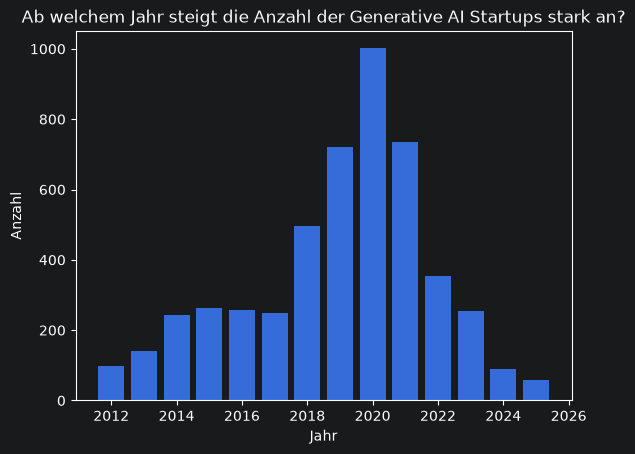

===Durchschnittsalter Der Unternehmen mit den Fundingstages Series C+ oder Pre-IPO 7.17 Jahre===


In [58]:
###Aufgabe 6 - Zeitanalyse: Grundungsjahr-Trends###

####Zahle Startups pro Grundungsjahr (.value_counts().sort_index())####
ZählerStartupsGründungsjahr = df["Founding_Year"].value_counts().sort_index()
print(f"===Zähler Startups im Jahr===\n {ZählerStartupsGründungsjahr}")

####Berechne Ø Total_Funding je Grundungsjahr####
Total_FundingJahr = df.groupby("Founding_Year").agg(
    Anzahl=('Company_ID', 'count'),
    Ø_Total_Funding=('Total_Funding_USD_Millions', 'mean')
)
print(f"===Ø Total_Funding je Grundungsjahr (In Mio.)===\n{Total_FundingJahr.sort_values('Ø_Total_Funding', ascending=False).round(2)}")

####Ab welchem Jahr steigt die Anzahl der Generative AI Startups stark an? (Filter + Jahresgruppe)####
AnstiegGenerativeAiFiltern = df[df["Domain"] == "Generative AI"]
AnstiegGenerativeAi = AnstiegGenerativeAiFiltern.groupby("Founding_Year").size()
print(f"===Statistik des Wachstums der Startups im KI-Bereich===\n {AnstiegGenerativeAi}")
#####Diagramm#####
plt.bar(AnstiegGenerativeAi.index,AnstiegGenerativeAi)
plt.title("Ab welchem Jahr steigt die Anzahl der Generative AI Startups stark an?")
plt.xlabel("Jahr")
plt.ylabel("Anzahl")
plt.show()

####Berechne wie viele Jahre alt die Startups im Durchschnitt sind, wenn sie Series C+ oder IPO erreichen####
FundingStageFiltern = df[df['Funding_Stage'].isin(['Series C+', 'Pre-IPO'])].copy()

FundingStageFiltern['Startup_Age'] = 2026 - FundingStageFiltern['Founding_Year']

print(f"===Durchschnittsalter Der Unternehmen mit den Fundingstages Series C+ oder Pre-IPO {FundingStageFiltern['Startup_Age'].mean().round(2)} Jahre===")

In [2]:
###Aufgabe 7 - KI-Adoption & Effizienz-Analyse###

####Vorarbiet####
df.isnull().sum()
df.isnull().sum() / len(df)
df.fillna("None", inplace=True)

####Berechne je AI_Adoption_Level: Ø Revenue_ARR, Ø Burn-Multiple, Ø Valuation####
AiAnalyse = df.groupby('AI_Adoption_Level').agg({
    "Revenue_ARR_Millions":     "mean",
    "Burn_Multiple":            "mean",
    "Valuation_USD_Millions":   "mean"
}).round(2)

print(f"===Analyse zur Wirtschaftsaspekten je KI-Intergartionsnivue===\n {AiAnalyse}")

####Vergleiche: Haben "High"-KI-Startups eine bessere Runway als "None"?####
HoherRunway = df[df["AI_Adoption_Level"] == "High"] ["Runway_Months_2024"].mean()
KeinRunway = df[df["AI_Adoption_Level"] == "None"] ["Runway_Months_2024"].mean()

print(f"===Haben *High*-KI-Startups eine bessere Runway als *None*?!===\n "
      f"Hohe KI-Integration = {HoherRunway.round(2)}\n"
      f"Gar keine KI-Integration = {KeinRunway.round(2)}")

####Erstelle eine Pivot-Tabelle: Zeilen = AI_Adoption_Level, Spalten = Funding_Stage, Werte = Ø Revenue_ARR####

PivotTabelle = df.pivot_table(
    values=     "Revenue_ARR_Millions",
    index=      "AI_Adoption_Level",
    columns=    "Funding_Stage",
    aggfunc=    "mean"
).round(2)

print(f"===PivotTabelle===\n{PivotTabelle}")

===Analyse zur Wirtschaftsaspekten je KI-Intergartionsnivue===
                    Revenue_ARR_Millions  Burn_Multiple  Valuation_USD_Millions
AI_Adoption_Level                                                             
High                              32.69           2.87                  457.28
Low                               31.36           2.87                  439.95
Medium                            35.26           2.85                  502.09
None                              33.77           2.82                  427.18
===Haben *High*-KI-Startups eine bessere Runway als *None*?!===
 Hohe KI-Integration = 12.24
Gar keine KI-Integration = 12.23
===PivotTabelle===
Funding_Stage      Post-IPO  Pre-IPO  Seed  Series A  Series B  Series C+
AI_Adoption_Level                                                        
High                 325.79   153.86  2.47      8.24     23.29      62.70
Low                  344.98   161.15  2.41      8.53     22.74      56.42
Medium               

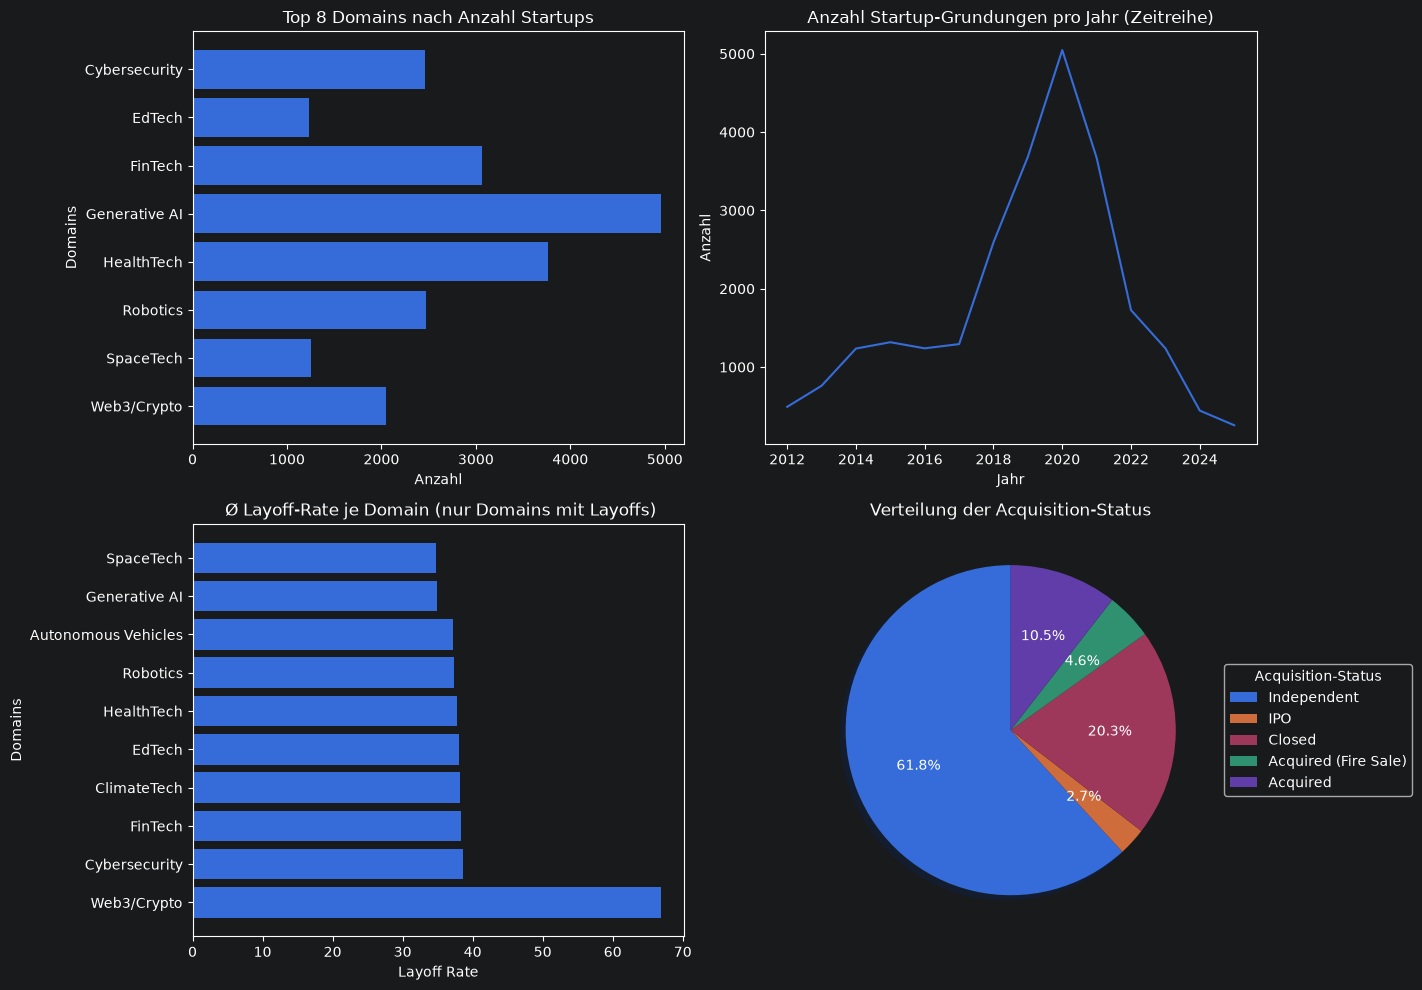

In [66]:
###Aufgabe 8 - Visualisierungen (4 Subplots)###

####Vorarbeit####
df.isnull().sum()
df.isnull().sum() / len(df)
df.fillna("0", inplace=True)

PlotEinsVorarbeit = df["Domain"].value_counts().sort_index(ascending=False).head(8)
PlotZweiVorarbiet = df["Founding_Year"].value_counts().sort_index(ascending=False)
PlotDreiVorarbeit = layoffs = df[df['Layoffs_2024_2025'] > 0]
PlotDreiVorarbeitEins = PlotDreiVorarbeit.groupby("Domain")["Layoff_Rate"].mean().sort_values(ascending=False)
PlotVierVorarbeiten = df["Acquisition_Status"].value_counts().sort_index(ascending=False)

####Diagramm####
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].barh(PlotEinsVorarbeit.index, PlotEinsVorarbeit.values)
axes[0, 0].set_title("Top 8 Domains nach Anzahl Startups")
axes[0, 0].set_xlabel("Anzahl")
axes[0, 0].set_ylabel("Domains")

axes[0, 1].plot(PlotZweiVorarbiet.index, PlotZweiVorarbiet.values)
axes[0, 1].set_title("Anzahl Startup-Grundungen pro Jahr (Zeitreihe)")
axes[0, 1].set_xlabel("Jahr")
axes[0, 1].set_ylabel("Anzahl")

axes[1, 0].barh(PlotDreiVorarbeitEins.index, PlotDreiVorarbeitEins.values)
axes[1, 0].set_title(" Ø Layoff-Rate je Domain (nur Domains mit Layoffs)")
axes[1, 0].set_xlabel("Layoff Rate")
axes[1, 0].set_ylabel("Domains")

axes[1, 1].pie(PlotVierVorarbeiten, shadow=True, startangle=90, autopct="%1.1f%%")
axes[1, 1].set_title("Verteilung der Acquisition-Status")
axes[1, 1].legend(
    PlotVierVorarbeiten.index,
    title="Acquisition-Status",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()
